## 0. Imports / Constants

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
from tqdm import tqdm

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
WIENER_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/unfolding'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
sys.path.insert(0,WIENER_DIR)
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')


#My imports
from sbnd.cafclasses.slice import CAFSlice
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import * # >= v2.2
from sbnd.general import plotters
from naming import *
from sbnd.general.utils import h5py_file_xrootd, read_hdf_xrootd, filter_by_common_indices
from sbnd.stats.systematics import Systematics

%load_ext autoreload
%autoreload 2

In [467]:
from datetime import date
day = date.today().strftime("%Y_%m_%d")

DATA_DIR = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
PNFS_DATA_DIR = '/pnfs/sbnd/persistent/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
VERSION = 'v5'
DET_VAR_DIR = os.path.join(DATA_DIR,'det_var')
PNFS_DET_VAR_DIR = os.path.join(PNFS_DATA_DIR,'det_var')
PLOT_DIR = f'{DATA_DIR}/plots/{day}/syst'
SAVE_DIR = f'{DATA_DIR}/data/{day}/syst'
os.makedirs(SAVE_DIR,exist_ok=True)

# Limit what gets processed
PROCESS_PDS = True
PROCESS_SCE = True
PROCESS_WIREMOD = True
PROCESS_CALO = True
PROCESS_COSMIC = True
PROCESS_SLIM = True


#CV sample with slim systematics
MC_SLIM_FNAME = f'{DATA_DIR}/mc_syst/{VERSION}/mc_smallpand_slimsyst_nocuts_norecomb3.df'

#Nominal sample which contains calo variations
MC_NOMINAL_FNAME = f'{DET_VAR_DIR}/nominal/v5/mc_nominal_nosyst_nocuts_recomb_small3.df'

#Calo variations, last index is nominal
if PROCESS_CALO:
  CALO_SUFFIXES = ["_alpha_embm1", "_beta_90m1", "_R_embm1","_alpha_embp1", "_beta_90p1", "_R_embp1","_c_cal_fracp1","_c_cal_fracm1"]
  CALO_VARS = [s[1:] for s in CALO_SUFFIXES]
else:
  CALO_VARS = []
  CALO_SUFFIXES = []

#PDS variations
PDS_MC_BASE_FNAME = MC_NOMINAL_FNAME.split('/')[-1]
PDS_VARS = ['pmtgain','pmtqe','pmtspe']
PDS_FNAMES = [f'{DET_VAR_DIR}/pds/{VERSION}/{PDS_MC_BASE_FNAME}'.replace('nominal',v).replace('recomb','norecomb') for v in PDS_VARS]

#SCE variations
SCE_MC_BASE_FNAME = MC_NOMINAL_FNAME.split('/')[-1]
SCE_VARS = ['nosce','twicesce']
SCE_FNAMES = [f'{DET_VAR_DIR}/sce/{VERSION}/{SCE_MC_BASE_FNAME}'.replace('nominal',v).replace('recomb','norecomb') for v in SCE_VARS]

#Wiremod variations
WIREMOD_MC_BASE_FNAME = MC_NOMINAL_FNAME.split('/')[-1]
WIREMOD_VARS = ['wiremodxtheta','wiremodyz']
WIREMOD_FNAMES = [f'{DET_VAR_DIR}/wiremod/{VERSION}/{WIREMOD_MC_BASE_FNAME}'.replace('nominal',v).replace('recomb','norecomb') for v in WIREMOD_VARS]

DET_VARS = []
DET_FNAMES = []
if PROCESS_PDS:
  DET_VARS += PDS_VARS
  DET_FNAMES += PDS_FNAMES
if PROCESS_SCE:
  DET_VARS += SCE_VARS
  DET_FNAMES += SCE_FNAMES
if PROCESS_WIREMOD:
  DET_VARS += WIREMOD_VARS
  DET_FNAMES += WIREMOD_FNAMES
#Get supplemental files
OFFBEAM_FNAME = f'{DATA_DIR}/offbeam/{VERSION}/mc_smallpand_nosyst_nocuts_recomb3.df'
DATA_OFFBEAM_FNAME = f'{DATA_DIR}/offbeam/{VERSION}/data_small_nocuts3.df'
DATA_FNAME = f'{DATA_DIR}/data/{VERSION}/dataonbeam_nocuts3.df'
MC_LOWE_SLIM_FNAME = f'{DATA_DIR}/mc_lowe/{VERSION}/mc_smallpand_slimsyst_nocuts_norecomb3.df'
MC_LOWE_FNAME = f'{DATA_DIR}/mc_lowe/{VERSION}/mc_smallpand_nosyst_nocuts_recomb3.df'


## 1. Load data

In [468]:
# Get keys for h5 files
import h5py

mcnu_keys = []
mcnu_lowe_keys = []
mcnu_keys = [[] for _ in range(len(DET_FNAMES))]
mcnu_nominal_keys = []
mcnu_slim_keys = []
mcnu_lowe_slim_keys = []

#Slices
mc_pand_keys = [[] for _ in range(len(DET_FNAMES))]
mc_nominal_pand_keys = []
mc_lowe_pand_keys = []
offbeam_pand_keys = []
offbeam_data_pand_keys = []
data_pand_keys = []
mc_slim_pand_keys = []
mc_lowe_slim_pand_keys = []
#Tracks
mc_trk_keys = []
mc_nominal_trk_keys = []
mc_lowe_trk_keys = []
offbeam_trk_keys = []
offbeam_data_trk_keys = []
data_trk_keys = []
mc_slim_trk_keys = []
mc_lowe_slim_trk_keys = []


#Headers
hdr_keys = [[] for _ in range(len(DET_FNAMES))] #Detector systematic headers
mc_nominal_hdr_keys = []
mc_lowe_hdr_keys = []
offbeam_hdr_keys = []
offbeam_data_hdr_keys = []
data_hdr_keys = []
mc_slim_hdr_keys = []
mc_lowe_slim_hdr_keys = []

#POT and total event keys
mc_pot_keys = [[] for _ in range(len(DET_FNAMES))]
mc_nominal_pot_keys = []
mc_lowe_pot_keys = []
offbeam_pot_keys = []
offbeam_data_pot_keys = []
data_pot_keys = []
mc_slim_pot_keys = []
mc_lowe_slim_pot_keys = []

mc_genevt_keys = [[] for _ in range(len(DET_FNAMES))]
mc_nominal_genevt_keys = []
mc_lowe_genevt_keys = []
offbeam_genevt_keys = []
offbeam_data_genevt_keys = []
data_genevt_keys = []
mc_slim_genevt_keys = []
mc_lowe_slim_genevt_keys = []

# Check the keys in the H5 Files
for fname in DET_FNAMES + [OFFBEAM_FNAME,DATA_FNAME,MC_NOMINAL_FNAME,MC_LOWE_FNAME,DATA_OFFBEAM_FNAME,MC_SLIM_FNAME,MC_LOWE_SLIM_FNAME]:
  print(f'File: {fname}')
  if not os.path.exists(fname):
    print(f'WARNING: File {fname} does not exist')
    continue
  with h5py_file_xrootd(fname) as f:
    # Store all keys at the root level
    if len(f.keys()) == 1:
      print(f'WARNING: File {fname} has insufficient keys')
    for key in f.keys():
      if 'pand' in key:
        if fname in DET_FNAMES:
          #Find index in DET_FNAMES
          idx = DET_FNAMES.index(fname)
          mc_pand_keys[idx].append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pand_keys.append(key)
        elif fname == DATA_FNAME:
          data_pand_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_pand_keys.append(key)
        elif fname == MC_NOMINAL_FNAME:
          mc_nominal_pand_keys.append(key)
        elif fname == DATA_OFFBEAM_FNAME:
          offbeam_data_pand_keys.append(key)
        elif fname == MC_SLIM_FNAME:
          mc_slim_pand_keys.append(key)
        elif fname == MC_LOWE_SLIM_FNAME:
          mc_lowe_slim_pand_keys.append(key)
      elif 'mcnu' in key:
        if fname in DET_FNAMES:
          #Find index in DET_FNAMES
          idx = DET_FNAMES.index(fname)
          mcnu_keys[idx].append(key)
        elif fname == MC_NOMINAL_FNAME:
          mcnu_nominal_keys.append(key)
        elif fname == MC_SLIM_FNAME:
          mcnu_slim_keys.append(key)
        elif fname == MC_LOWE_SLIM_FNAME:
          mcnu_lowe_slim_keys.append(key)
      elif 'hdr' in key:
        if fname in DET_FNAMES:
          idx = DET_FNAMES.index(fname)
          hdr_keys[idx].append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_hdr_keys.append(key)
        elif fname == DATA_FNAME:
          data_hdr_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_hdr_keys.append(key)
        elif fname == MC_NOMINAL_FNAME:
          mc_nominal_hdr_keys.append(key)
        elif fname == DATA_OFFBEAM_FNAME:
          offbeam_data_hdr_keys.append(key)
        elif fname == MC_SLIM_FNAME:
          mc_slim_hdr_keys.append(key)
        elif fname == MC_LOWE_SLIM_FNAME:
          mc_lowe_slim_hdr_keys.append(key)
        else:
          print(f'WARNING: Unknown file: {fname} for key: {key}')
      elif 'histpotdf' in key:
        if fname in DET_FNAMES:
          idx = DET_FNAMES.index(fname)
          mc_pot_keys[idx].append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pot_keys.append(key)
        elif fname == DATA_FNAME:
          data_pot_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_pot_keys.append(key)
        elif fname == MC_NOMINAL_FNAME:
          mc_nominal_pot_keys.append(key)
        elif fname == DATA_OFFBEAM_FNAME:
          offbeam_data_pot_keys.append(key)
        elif fname == MC_SLIM_FNAME:
          mc_slim_pot_keys.append(key)
        elif fname == MC_LOWE_SLIM_FNAME:
          mc_lowe_slim_pot_keys.append(key)
        else:
          print(f'WARNING: Unknown file: {fname} for key: {key}')
      elif 'histgenevtdf' in key:
        if fname in DET_FNAMES:
          idx = DET_FNAMES.index(fname)
          mc_genevt_keys[idx].append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_genevt_keys.append(key)
        elif fname == DATA_FNAME:
          data_genevt_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_genevt_keys.append(key)
        elif fname == MC_NOMINAL_FNAME:
          mc_nominal_genevt_keys.append(key)
        elif fname == DATA_OFFBEAM_FNAME:
          offbeam_data_genevt_keys.append(key)
        elif fname == MC_SLIM_FNAME:
          mc_slim_genevt_keys.append(key)
        elif fname == MC_LOWE_SLIM_FNAME:
          mc_lowe_slim_genevt_keys.append(key)
        else:
          print(f'WARNING: Unknown file: {fname} for key: {key}')

File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/pds/v5/mc_pmtgain_nosyst_nocuts_norecomb_small3.df


File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/pds/v5/mc_pmtqe_nosyst_nocuts_norecomb_small3.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/pds/v5/mc_pmtspe_nosyst_nocuts_norecomb_small3.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/sce/v5/mc_nosce_nosyst_nocuts_norecomb_small3.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/sce/v5/mc_twicesce_nosyst_nocuts_norecomb_small3.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/wiremod/v5/mc_wiremodxtheta_nosyst_nocuts_norecomb_small3.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/wiremod/v5/mc_wiremodyz_nosyst_nocuts_norecomb_small3.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/offbeam/v5/mc_smallpand_nosyst_nocuts_recomb3.df
File

In [542]:
#Get POT from nominal h5
POT_NOMINAL = 0
for key in mc_nominal_pot_keys:
  potdf_mc_nominal = read_hdf_xrootd(MC_NOMINAL_FNAME,key=key)
  POT_NOMINAL += potdf_mc_nominal.TotalPOT.values.sum()
print(f'POT_NOMINAL: {POT_NOMINAL:.2e}')

#Get POT from the h5
POT_DETS = np.zeros(len(DET_FNAMES))
for i,fname in tqdm(enumerate(DET_FNAMES),unit=' read det POT'):
  for key in mc_pot_keys[i]:
    potdf_mc = read_hdf_xrootd(fname,key=key)
    POT_DETS[i] += potdf_mc.TotalPOT.values.sum()
print(f'POT_DETS: ',POT_DETS)

POT_MC_LOWE = 0
# for key in mc_lowe_pot_keys:
#   potdf_mc_lowe = read_hdf_xrootd(MC_LOWE_FNAME,key=key)
#   POT_MC_LOWE += potdf_mc_lowe.TotalPOT.values.sum()
for key in mc_lowe_hdr_keys:
  potdf_mc_lowe = read_hdf_xrootd(MC_LOWE_FNAME,key=key)
  POT_MC_LOWE += potdf_mc_lowe.pot.values.sum()
print(f'POT_MC_LOWE: {POT_MC_LOWE:.2e}')

POT_MC_SLIM = 0
for key in mc_slim_pot_keys:
  potdf_mc_slim = read_hdf_xrootd(MC_SLIM_FNAME,key=key)
  POT_MC_SLIM += potdf_mc_slim.TotalPOT.values.sum()
print(f'POT_MC_SLIM: {POT_MC_SLIM:.2e}')

POT_MC_LOWE_SLIM = 0
for key in mc_lowe_slim_pot_keys:
  potdf_mc_lowe_slim = read_hdf_xrootd(MC_LOWE_SLIM_FNAME,key=key)
  POT_MC_LOWE_SLIM += potdf_mc_lowe_slim.TotalPOT.values.sum()
print(f'POT_MC_LOWE_SLIM: {POT_MC_LOWE_SLIM:.2e}')

LIVETIME_OFFBEAM = 0
for key in offbeam_genevt_keys:
  genevt_offbeam = read_hdf_xrootd(OFFBEAM_FNAME,key=key)
  LIVETIME_OFFBEAM += genevt_offbeam.TotalGenEvents.values.sum()
# for key in offbeam_hdr_keys:
#   hdr_offbeam = read_hdf_xrootd(OFFBEAM_FNAME,key=key)
#   LIVETIME_OFFBEAM += hdr_offbeam.ngenevt.values.sum()
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')

LIVETIME_OFFBEAM_DATA = 0
# for key in offbeam_data_genevt_keys:
#   genevt_offbeam_data = read_hdf_xrootd(DATA_OFFBEAM_FNAME,key=key)
#   LIVETIME_OFFBEAM_DATA += genevt_offbeam_data.TotalGenEvents.values.sum()
for key in offbeam_data_hdr_keys:
  hdr_offbeam_data = read_hdf_xrootd(DATA_OFFBEAM_FNAME,key=key)
  LIVETIME_OFFBEAM_DATA += hdr_offbeam_data.noffbeambnb.values.sum()
print(f'LIVETIME_OFFBEAM_DATA: {LIVETIME_OFFBEAM_DATA:.2e}')

LIVETIME_DATA = 0
POT_DATA = 0
for key in data_hdr_keys:
  hdr_data = read_hdf_xrootd(DATA_FNAME,key=key)
  LIVETIME_DATA += hdr_data.noffbeambnb.values.sum()
  POT_DATA += hdr_data.pot.values.sum()
LIVETIME_DATA = 9.51e5 # Temporary
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
print(f'POT_DATA: {POT_DATA:.2e}')
POT_LABEL = f'{POT_DATA:.2e} POT'
#print('WARNING: Setting LIVETIME_OFFBEAM to LIVETIME_DATA for now')
#LIVETIME_OFFBEAM = LIVETIME_DATA

POT_NOMINAL: 1.03e+19


7 read det POT [00:04,  1.48 read det POT/s]


POT_DETS:  [1.50493199e+19 1.50577488e+19 1.50483080e+19 1.50585547e+19
 1.50496972e+19 7.52877371e+18 7.52832908e+18]
POT_MC_LOWE: 5.93e+18
POT_MC_SLIM: 3.00e+18
POT_MC_LOWE_SLIM: 6.03e+18
LIVETIME_OFFBEAM: 4.89e+05
LIVETIME_OFFBEAM_DATA: 2.00e+06
LIVETIME_DATA: 9.51e+05
POT_DATA: 5.95e+18


In [566]:
#Load, but also replace nan E with truth E to do reference matching
slcs = [None]*(len(DET_FNAMES)+1)
slc = CAFSlice.load(MC_NOMINAL_FNAME,key=mc_nominal_pand_keys)
#Set the nominal variation
slcs[-1] = slc
slc_lowe = CAFSlice.load(MC_LOWE_FNAME,key=mc_lowe_pand_keys)

for i,fname in tqdm(enumerate(DET_FNAMES),unit=' goomba'):
  _slc = CAFSlice.load(fname,key=mc_pand_keys[i])
  slcs[i] = _slc

# Off beam
slc_offbeam_data = CAFSlice.load(DATA_OFFBEAM_FNAME,key=offbeam_data_pand_keys)
if PROCESS_COSMIC:
  # Only need off beam if we are processing off beam
  slc_offbeam = CAFSlice.load(OFFBEAM_FNAME,key=offbeam_pand_keys)
# CV sample with slim systematics
if PROCESS_SLIM:
  slc_slim = CAFSlice.load(MC_SLIM_FNAME,key=mc_slim_pand_keys)
  slc_lowe_slim = CAFSlice.load(MC_LOWE_SLIM_FNAME,key=mc_lowe_slim_pand_keys)

# Data, why not
slc_data = CAFSlice.load(DATA_FNAME,key=data_pand_keys)

7 goomba [01:44, 14.96s/ goomba]


In [ ]:
# Load hdrs for det variations
hdrs = [None]*(len(DET_FNAMES)+1)
hdrs[-1] = read_hdf_xrootd(MC_NOMINAL_FNAME,key=mc_nominal_hdr_keys)
hdrs[-1]

[                         pot  first_in_subrun  ismc  run  subrun  ngenevt  \
 __ntuple entry                                                              
 0        0      9.465921e+14                1     1    1      92       50   
          1      0.000000e+00                0     1    1      92       50   
          2      0.000000e+00                0     1    1      92       50   
          3      0.000000e+00                0     1    1      92       50   
          4      0.000000e+00                0     1    1      92       50   
 ...                      ...              ...   ...  ...     ...      ...   
 1326     80     0.000000e+00                0     1   31      60       50   
          81     0.000000e+00                0     1   31      60       50   
          82     0.000000e+00                0     1   31      60       50   
          83     0.000000e+00                0     1   31      60       50   
          84     0.000000e+00                0     1   31      6

### 1.0 Filter det variations to unique run, subrun, event, neutrino energy

In [567]:
FILTER = True

In [569]:
_slcs = [s.copy() for s in slcs]

In [ ]:
og_lens = [len(s.data) for s in slcs]
if FILTER:
  for i,_slc in tqdm(enumerate(slcs),unit=' filter det dataframes', total=len(slcs)):
    #To ensure we keep only the common events
    print(f'{i}^th slice has {len(_slc.data)} events')
    print(f'nominal slice has {len(slcs[-1].data)} events')
    _df_ref, df_nominal = filter_by_common_indices(_slc.data,slcs[-1].data,['run','subrun','evt'],keep_nan=False)
    if len(_df_ref) == 0 or len(df_nominal) == 0:
      raise ValueError(f'{i}^th slice has no data (df_nominal: {len(df_nominal)}, _df_ref: {len(_df_ref)})')
    #print(f'- {i}^th slice has {len(_df_ref)} events')
    #print(f'- nominal slice has {len(df_nominal)} events')
    #Match by run, subrun, event, neutrino energy
    _df_ref, df_nominal = filter_by_common_indices(_df_ref,df_nominal,['run','subrun','evt',('truth','E')])
    if len(_df_ref) == 0 or len(df_nominal) == 0:
      raise ValueError(f'{i}^th slice has no data (df_nominal: {len(df_nominal)}, _df_ref: {len(_df_ref)})')
    #print(f'- {i}^th slice has {len(_df_ref)} events')
    #print(f'- nominal slice has {len(df_nominal)} events')
    slcs[i] = CAFSlice(_df_ref)
    slcs[-1] = CAFSlice(df_nominal)

  # Refilter so all detector variations have the same number of slices
  for i,_slc in tqdm(enumerate(slcs),unit=' refilter slices', total=len(slcs)):
    _df_ref, df_nominal = filter_by_common_indices(_slc.data,slcs[-1].data,['run','subrun','evt'], keep_nan=False)
    #Match by run, subrun, event, neutrino energy
    _df_ref, df_nominal = filter_by_common_indices(_df_ref,df_nominal,['run','subrun','evt',('truth','E')])
    slcs[i] = CAFSlice(_df_ref)
    slcs[-1] = CAFSlice(df_nominal)

# Scale pot_min to the ratio of the original length of the pot_min slice to the length after refiltering
new_lens = [len(s.data) for s in slcs]
#print(f'Scaling pot_min from {pot_min:.2e} -> {pot_min*new_len/og_len:.2e}')

for i,_slc in enumerate(slcs):
  if i == len(slcs)-1:
    pot = POT_NOMINAL
    print(f'Scaling pot_min from {pot:.2e} -> {pot*new_lens[i]/og_lens[i]:.2e}')
    pot = pot*new_lens[i]/og_lens[i]
  else:
    pot = POT_DETS[i]
    print(f'Scaling pot_min from {pot:.2e} -> {pot*new_lens[i]/og_lens[i]:.2e}')
    pot = pot*new_lens[i]/og_lens[i]
  _slc.pot = pot
  _slc.scale_to_pot(POT_DATA,sample_pot=pot,overwrite=True)

  0%|          | 0/8 [00:00<?, ? filter det dataframes/s]

0^th slice has 1544721 events
nominal slice has 1054328 events


 12%|█▎        | 1/8 [00:37<04:20, 37.17s/ filter det dataframes]

1^th slice has 1551924 events
nominal slice has 566706 events


In [595]:
cols = _slcs[-1].get_key(['run','subrun','evt'])
unique_runs = _slcs[-1].data.loc[:,cols].drop_duplicates()

iters = 0
bad_iters = 0
for j,row in unique_runs.iterrows():
  run,subrun,evt = row
  column_counts = []
  for i,s in enumerate(_slcs):
    m1 = (s.data.run == run) & (s.data.subrun == subrun) & (s.data.evt == evt)
    column_counts.append(len(s.data.loc[m1]))
  if len(set(column_counts)) > 1:
    print(f'Broken after {iters}/{len(unique_runs)} runs')
    print(f'{run},{subrun},{evt}: {column_counts}')
    bad_iters += 1
    if bad_iters > 6:
      break
  
  iters += 1
  

Broken after 0/21053 runs
1,92,14: [28, 28, 19, 28, 28, 16, 16, 28]
Broken after 1/21053 runs
1,92,21: [29, 29, 17, 29, 29, 18, 20, 29]
Broken after 2/21053 runs
1,92,23: [31, 31, 31, 31, 31, 26, 26, 31]
Broken after 3/21053 runs
1,92,27: [32, 32, 24, 32, 32, 19, 20, 32]
Broken after 4/21053 runs
1,92,28: [13, 13, 5, 13, 13, 8, 8, 13]
Broken after 5/21053 runs
1,92,37: [16, 16, 16, 16, 16, 8, 9, 16]
Broken after 6/21053 runs
1,92,48: [20, 20, 20, 20, 20, 10, 11, 20]


In [596]:
cols = _slcs[-1].get_key(['run','subrun','evt','truth.E'])

In [602]:
_slcs[-1].data.truth.ind

__ntuple  entry  rec.slc..index
0         2      1                NaN
                 2                NaN
                 3                NaN
                 4                NaN
                 5                NaN
                                   ..
1261      29     0                NaN
                 2                NaN
                 3                NaN
                 4                NaN
                 5                NaN
Name: ind, Length: 243300, dtype: float64

In [597]:
DET_VARS[-2],DET_VARS[2]

('wiremodxtheta', 'pmtspe')

In [598]:
s = _slcs[2]
m = (s.data.run == run) & (s.data.subrun == subrun) & (s.data.evt == evt)# & (s.data.index.get_level_values(1).values == 82)
s.data.loc[m,cols]


,,,run,subrun,evt,truth
,,,,,,E
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
__ntuple,entry,rec.slc..index,,,,
4,61,0,1,92,48,NaN


In [599]:
s = _slcs[-2]
m = (s.data.run == run) & (s.data.subrun == subrun) & (s.data.evt == evt)
s.data.loc[m,cols]


,,,run,subrun,evt,truth
,,,,,,E
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
__ntuple,entry,rec.slc..index,,,,
106,14,0,1,92,48,NaN


,,,run,subrun,evt,truth
,,,,,,E
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
__ntuple,entry,rec.slc..index,,,,
197,82,0,1,92,37,4.088


In [476]:
# for i,_slc in enumerate(slcs):
#   if i == len(slcs):
#     pot = POT_NOMINAL
#     print(f'Scaling pot_min from {pot:.2e} -> {pot*new_lens[i]/og_lens[i]:.2e}')
#     pot = pot*new_lens[i]/og_lens[i]
#   else:
#     pot = POT_DETS[i]
#     print(f'Scaling pot_min from {pot:.2e} -> {pot*new_lens[i]/og_lens[i]:.2e}')
#     pot = pot*new_lens[i]/og_lens[i]
#   _slc.pot = pot
#   _slc.scale_to_pot(POT_DATA,sample_pot=pot,overwrite=True)

### 1.1 Rescale to MC POT and combine off beam

In [ ]:
#Rescale to DATA
slc_lowe.scale_to_pot(POT_DATA,sample_pot=POT_MC_LOWE)
slc_offbeam.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM,overwrite=True)
slc_offbeam_data.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM_DATA,overwrite=True)

#Slim
if PROCESS_SLIM:
  slc_slim.scale_to_pot(POT_DATA,sample_pot=POT_MC_SLIM,overwrite=True)
  slc_lowe_slim.scale_to_pot(POT_DATA,sample_pot=POT_MC_LOWE_SLIM,overwrite=True)


--scaling to POT (1.00e+00): 5.93e+18 -> 5.95e+18
--scaling to livetime (1.94e+00): 4.89e+05 --> 9.51e+05
--scaling to livetime (4.76e-01): 2.00e+06 --> 9.51e+05
--scaling to POT (1.98e+00): 3.00e+18 -> 5.95e+18
--scaling to POT (9.87e-01): 6.03e+18 -> 5.95e+18


In [ ]:
#Combine off beam to each slice
for i,slc in tqdm(enumerate(slcs),unit=' combine samples',total=len(slcs)):
  slc.combine(slc_offbeam_data,duplicate_ok=True)
  slc.combine(slc_lowe,duplicate_ok=True,offset=int(2e5))
#del slc_lowe
if PROCESS_SLIM:
  slc_slim.combine(slc_offbeam_data,duplicate_ok=True)
  slc_slim.combine(slc_lowe_slim,duplicate_ok=True,offset=int(2e5))
  #del slc_lowe_slim
if not PROCESS_COSMIC:
  del slc_offbeam
  del slc_offbeam_data

100%|██████████| 8/8 [00:28<00:00,  3.60s/ combine samples]


In [ ]:
# plt.hist([slc_data.data.slc.barycenterFM.flashPEs, slc_slim.data.slc.barycenterFM.flashPEs],
# bins=np.arange(0,10000,100),weights=[slc_data.data.genweight, slc_slim.data.genweight],histtype='step',label=['data','slim'],density=True)
# plt.legend();

### 1.2 Create signal slices

In [ ]:
slcs_sig = [None]*(len(DET_FNAMES)+1)

for i,slc in tqdm(enumerate(slcs),unit=' goomba', total=len(slcs)):
  #Signal - filter using truth event type
  truth_event_type_col = slc.get_key('truth.event_type')[0]
  sig_mask = np.isin(slc.data[truth_event_type_col].values, [0,1])
  slcs_sig[i] = CAFSlice(slc.data.loc[sig_mask], pot=slc.pot)

#Slim
if PROCESS_SLIM:
  truth_event_type_col = slc_slim.get_key('truth.event_type')[0]
  sig_mask = np.isin(slc_slim.data[truth_event_type_col].values, [0,1])
  slc_slim_sig = CAFSlice(slc_slim.data[sig_mask], pot=slc_slim.pot)

  0%|          | 0/8 [00:00<?, ? goomba/s]

100%|██████████| 8/8 [00:00<00:00,  9.96 goomba/s]


In [ ]:
for i,s in enumerate(slcs_sig+slcs):
  assert len(s.data) > 0, f'{i}^th slices have no data'

### 1.3 Assign binnings

In [ ]:
# Binning 2d class
from sbnd.cafclasses.binning import Binning2D
binning2d = Binning2D()

In [ ]:
costheta_bins = COSTHETA_BINS
momentum_bins = MOMENTUM_BINS
differential_edges = binning2d.differential_edges

In [ ]:
#This should be empty
for s in slcs_sig:
  m1 = s.data.true_bin.differential == -1
  assert len(s.data[m1]) == 0, f'{len(s.data[m1])} slices have no differential bin'

### 1.4 Get binnings

In [ ]:
#Get distribution after all cuts
# -- signal
reco_sig_costhetas = [s.data.mu.pfp.trk.costheta for s in slcs_sig]
reco_sig_moms = [s.data.mu.pfp.trk.P.p_muon for s in slcs_sig]
reco_sig_differential_bins = [s.data.bin.differential for s in slcs_sig]
# --- cut variables
# reco_sig_opt0 = [s.data.slc.opt0.score for s in slcs_sig]
reco_sig_bcfms = [s.data.slc.barycenterFM.score for s in slcs_sig]
#reco_sig_nuscore = [s.data.slc.nu_score for s in slcs_sig]
reco_sig_flashpe = [s.data.slc.barycenterFM.flashPEs for s in slcs_sig]

# -- signal signal
true_sig_costhetas = [s.data.truth.mu.dir.z for s in slcs_sig]
true_sig_moms = [s.data.truth.mu.totp for s in slcs_sig]
true_sig_differential_bins = [s.data.true_bin.differential for s in slcs_sig]

# Genweights
genweights_sig = [s.data.genweight for s in slcs_sig]

if PROCESS_SLIM:
  reco_sig_costhetas_slim = slc_slim_sig.data.mu.pfp.trk.costheta
  reco_sig_moms_slim = slc_slim_sig.data.mu.pfp.trk.P.p_muon
  reco_sig_differential_bins_slim = slc_slim_sig.data.bin.differential

  #reco_sig_opt0_slim = slc_slim_sig.data.slc.opt0.score
  reco_sig_bcfms_slim = slc_slim_sig.data.slc.barycenterFM.score
  #reco_sig_nuscore_slim = slc_slim_sig.data.slc.nu_score
  reco_sig_flashPEs_slim = slc_slim_sig.data.slc.barycenterFM.flashPEs

  true_sig_costhetas_slim = slc_slim_sig.data.truth.mu.dir.z
  true_sig_moms_slim = slc_slim_sig.data.truth.mu.totp
  true_sig_differential_bins_slim = slc_slim_sig.data.true_bin.differential

  genweights_slim_sig = slc_slim_sig.data.genweight

### 1.5 Check plots

In [ ]:
# _slcs_sel = slcs[0].copy()
# _slcs_sel.cut_all(cut=True)

# _slc_slim = slc_slim.copy()
# _slc_slim.cut_all(cut=True)

In [ ]:
__reco_sel_costhetas_data,_ = np.histogram(_slcs_sel.data.mu.pfp.trk.costheta,bins=COSTHETA_BINS,weights=_slcs_sel.data.genweight)
__reco_sel_moms_data,_ = np.histogram(_slcs_sel.data.mu.pfp.trk.P.p_muon,bins=MOMENTUM_BINS,weights=_slcs_sel.data.genweight)

__reco_sel_costhetas_slim_data,_ = np.histogram(_slc_slim.data.mu.pfp.trk.costheta,bins=COSTHETA_BINS,weights=_slc_slim.data.genweight)
__reco_sel_moms_slim_data,_ = np.histogram(_slc_slim.data.mu.pfp.trk.P.p_muon,bins=MOMENTUM_BINS,weights=_slc_slim.data.genweight)

In [ ]:
__reco_sel_moms_data,__reco_sel_moms_slim_data

(array([1601.91710409, 3187.36242641, 2423.94659713, 1563.7505824 ,
         866.91062426,  465.97793237,  250.27192017,  284.7185054 ,
         120.73524775,   68.41676624]),
 array([3011.74698384, 5727.36989911, 4338.13138668, 2679.81674707,
        1392.76204747,  803.11743802,  461.41336247,  492.04686531,
         216.30481222,  104.38291767]))

In [83]:
len(_slcs_sel.data.genweight),len(_slc_slim.data.genweight)

(5924, 11079)

In [ ]:
_slc_slim.data.genweight.unique(),_slcs_sel[0].data.genweight.unique()


(array([1.98146892, 0.47640422, 0.98732112]),
 array([0.47640422, 2.23433951, 1.00307404]))

## 2. Process detector systematics

In [ ]:
#Get the variables to initialize systematics
XSEC_UNIT = np.float64(np.loadtxt(f'{DATA_DIR}/data/2026_01_08/syst/metadata/xsec_unit.csv')) #Check this

In [ ]:
# At each cut, we want to...
# 0. Intiialize slices for storage
# 1. Apply cut
# 2. Get selected events broken into signal and background.
# 3. Get event rates for detector variations
# 4. Construct systematic objects
# 5. Process systematics using stored values
# 6. Compute covariances and combine objects
# 7. Combine into summary systematics and save
# 8. Compute chi2 with data
# 9. Plots
COPY = True
PROC_STEPS = [0,1,2,3,4,5,6,7,8,9] #Everything
#PROC_STEPS = [9]
#TODO: 

from time import time
#Only use copy for testing, afterwards use slcs since we only need it for this purpose
tc0 = time()
#Keep track of offbeam separately to get cosmic uncertainty
if COPY:
  _slcs = [slc.copy() for slc in slcs]
  if PROCESS_COSMIC:
    _slc_sel_offbeam = slc_offbeam.copy()
    _slc_sel_offbeam_data = slc_offbeam_data.copy()
  if PROCESS_SLIM:
    _slc_slim = slc_slim.copy()
  _slc_data = slc_data.copy()
else:
  _slcs = slcs
  if PROCESS_COSMIC:
    _slc_sel_offbeam = slc_offbeam
    _slc_sel_offbeam_data = slc_offbeam_data
  if PROCESS_SLIM:
    _slc_slim = slc_slim
  _slc_data = slc_data
_slcs_calo = [] # For the case where we do not process calo, this needs to be empty
tc1 = time()
print(f'Time to copy slices: {tc1-tc0:.2f} seconds')
#Set some binnings
BCFM_BINS = np.arange(0,1.1,0.025)
#OPT0_BINS = (1/np.logspace(-7,1,140))[::-1] #Flip since opt0 is not inverted
#NUSCORE_BINS = np.arange(-1,1.025,0.025)
FLASHPE_BINS = np.arange(0,10500,500)

from time import time

for cut in ['precut']+PAND_CUTS:
#for cut in ['lowz']:
  print('*'*30,f' cut: {cut} ','*'*30)

  # 0. Intiialize slices for storage
  if 0 in PROC_STEPS:
    _slcs_sel = [None]*(len(DET_FNAMES)+1)
    _slcs_sel_background = [None]*(len(DET_FNAMES)+1)
    _slcs_sel_calo = [None]*(len(CALO_VARS))
    _slcs_sel_background_calo = [None]*(len(CALO_VARS))
    subfolder = f'{DATA_DIR}/data/{day}/syst/{cut}'
  else:
    print('Skipping initialization of slices')
  # 1. Apply cut
  t0 = time()
  if 1 in PROC_STEPS:
    if cut == 'muon' and PROCESS_CALO:
      #Make a copy for calo variations
      _slcs_calo = [None]*len(CALO_VARS)
      for i in range(len(CALO_VARS)):
        _slcs_calo[i] = _slcs[-1].copy()
    if cut != 'precut':
      #print(f'Nominal length before cut: {len(_slcs[-1].data)}')
      [s.apply_cut(cut) for s in _slcs]
      _slc_data.apply_cut(cut)
      #print(f'Nominal length after cut: {len(_slcs[-1].data)}')
      #_slc_sel_data.apply_cut(cut)
      if PROCESS_COSMIC:
        _slc_sel_offbeam.apply_cut(cut)
        _slc_sel_offbeam_data.apply_cut(cut)
      if PROCESS_SLIM:
        _slc_slim.apply_cut(cut)
    #For the calo variations beyond muon, we just apply the nominal cut
    if PROCESS_CALO:
      if cut in ['cosmic','lowz']: 
        [s.apply_cut(cut) for s in _slcs_calo]
      elif cut == 'muon':
        for i,(slc,suffix) in enumerate(zip(_slcs_calo,CALO_SUFFIXES)):
          has_muon_key = f'has_muon{suffix}'
          has_muon_col = slc.get_key(has_muon_key)[0]
          # Replace cosmic col with whatever variation we are doing
          mask = [ind[-1] >= int(1e5) for ind in list(slc.data.index)]
          values = np.array(slc.data[mask].has_muon.values,dtype=bool)
          _slcs_calo[i].add_cols(has_muon_key,values,conditions=mask,fill=False,verbose=False)
          #print(f'Len of {has_muon_col} before cut: {len(slc.data[has_muon_col])}')
          _slcs_calo[i].data = _slcs_calo[i].data[slc.data[has_muon_col] == True]
          #print(f'Len of {has_muon_col} after cut: {len(_slcs_calo[i].data[has_muon_col])}')
      else:
        print(f'Skipping calo variations for {cut}')
  else:
    print('Skipping applying cut')
  t1 = time()
  print(f'Time to apply cut: {t1-t0:.2f} seconds')
  # 2. Get selected events broken into signal and background. Also just the signal events
  if 2 in PROC_STEPS:
    for i,slc in enumerate(_slcs):
      #Signal - filter using truth event type
      sig_mask = np.isin(slc.data.truth.event_type, [0,1])
      bg_mask = ~sig_mask
      #Selection - filter using cut.all column and has_muon
      _slcs_sel[i] = CAFSlice(slc.data[sig_mask], pot=slc.pot)
      #Background - filter using cut.all column, and is not signal has_muon
      _slcs_sel_background[i] = CAFSlice(slc.data[bg_mask], pot=slc.pot)
    
    #Rely on nominal being last processed slice
    if PROCESS_COSMIC:
      # Remove off beam events
      cosmic_mask = np.array([ind[-1] >= int(1e5) and ind[-1] < int(2e5) for ind in list(slc.data.index)],dtype=bool) 
      _slc_sel_background_nocosmic = CAFSlice(_slcs[-1].data[bg_mask & ~cosmic_mask], pot=_slcs[-1].pot)
    if cut in ['muon','cosmic','lowz'] and PROCESS_CALO:
      #print('Breaking calo into signal / background')
      for i,slc in enumerate(_slcs_calo):
        #Signal - filter using truth event type
        sig_mask = np.isin(slc.data.truth.event_type, [0,1])
        bg_mask = ~sig_mask
        #Selection - filter using cut.all column and has_muon
        #print(f'({i}) Signal mask: {sig_mask.sum()}/{len(sig_mask)}')
        #print(f'({i}) Background mask: {bg_mask.sum()}/{len(bg_mask)}')
        _slcs_sel_calo[i] = CAFSlice(slc.data[sig_mask], pot=slc.pot)
        _slcs_sel_background_calo[i] = CAFSlice(slc.data[bg_mask], pot=slc.pot)
    if PROCESS_SLIM:
      sig_mask = np.isin(_slc_slim.data.truth.event_type, [0,1])
      bg_mask = ~sig_mask
      _slc_slim_sel = CAFSlice(_slc_slim.data[sig_mask], pot=_slc_slim.pot)
      _slc_slim_sel_background = CAFSlice(_slc_slim.data[bg_mask], pot=_slc_slim.pot)
  else:
    print('Skipping getting selected events')
  t2 = time()
  print(f'Time to get selected events: {t2-t1:.2f} seconds')
  if 3 in PROC_STEPS:
    # 3. Get event rates for detector variations
    # 3.1 Detector variations
    #Get distribution after all cuts
    # - reco quantities
    # -- selected signal
    _reco_sel_costhetas = [s.data.mu.pfp.trk.costheta for s in _slcs_sel]
    _reco_sel_moms = [s.data.mu.pfp.trk.P.p_muon for s in _slcs_sel]
    _reco_sel_differential_bins = [s.data.bin.differential for s in _slcs_sel]

    # --- cut variables
    reco_sel_bcfms = [s.data.slc.barycenterFM.score for s in _slcs_sel]
    reco_sel_flashpe = [s.data.slc.barycenterFM.flashPEs for s in _slcs_sel]

    # -- background
    _reco_bg_costhetas = [s.data.mu.pfp.trk.costheta for s in _slcs_sel_background]
    _reco_bg_moms = [s.data.mu.pfp.trk.P.p_muon for s in _slcs_sel_background]
    _reco_bg_differential_bins = [s.data.bin.differential for s in _slcs_sel_background]
    # --- cut variables
    reco_bg_bcfms = [s.data.slc.barycenterFM.score for s in _slcs_sel_background]
    reco_bg_flashpe = [s.data.slc.barycenterFM.flashPEs for s in _slcs_sel_background]

    # -- background no cosmic
    _reco_bg_nocosmic_costhetas = _slc_sel_background_nocosmic.data.mu.pfp.trk.costheta
    _reco_bg_nocosmic_moms = _slc_sel_background_nocosmic.data.mu.pfp.trk.P.p_muon
    _reco_bg_nocosmic_differential_bins = _slc_sel_background_nocosmic.data.bin.differential
    reco_bg_nocosmic_bcfms = _slc_sel_background_nocosmic.data.slc.barycenterFM.score
    reco_bg_nocosmic_flashpe = _slc_sel_background_nocosmic.data.slc.barycenterFM.flashPEs

    # - true quantities
    # -- selected signal
    _true_sel_costhetas = [s.data.truth.mu.dir.z for s in _slcs_sel]
    _true_sel_moms = [s.data.truth.mu.totp for s in _slcs_sel]
    _true_sel_differential_bins = [s.data.true_bin.differential for s in _slcs_sel]

    # # -- background
    _true_bg_costhetas = [s.data.truth.mu.dir.z for s in _slcs_sel_background]
    _true_bg_moms = [s.data.truth.mu.totp for s in _slcs_sel_background]
    _true_bg_differential_bins = [s.data.true_bin.differential for s in _slcs_sel_background]

    if PROCESS_SLIM:
      _reco_sel_costhetas_slim = _slc_slim_sel.data.mu.pfp.trk.costheta
      _reco_sel_moms_slim = _slc_slim_sel.data.mu.pfp.trk.P.p_muon
      _reco_sel_differential_bins_slim = _slc_slim_sel.data.bin.differential

      reco_sel_bcfms_slim = _slc_slim_sel.data.slc.barycenterFM.score
      reco_sel_flashpe_slim = _slc_slim_sel.data.slc.barycenterFM.flashPEs

      _reco_bg_costhetas_slim = _slc_slim_sel_background.data.mu.pfp.trk.costheta
      _reco_bg_moms_slim = _slc_slim_sel_background.data.mu.pfp.trk.P.p_muon
      _reco_bg_differential_bins_slim = _slc_slim_sel_background.data.bin.differential

      reco_bg_bcfms_slim = _slc_slim_sel_background.data.slc.barycenterFM.score
      reco_bg_flashpe_slim = _slc_slim_sel_background.data.slc.barycenterFM.flashPEs

      _true_sel_costhetas_slim = _slc_slim_sel.data.truth.mu.dir.z
      _true_sel_moms_slim = _slc_slim_sel.data.truth.mu.totp
      _true_sel_differential_bins_slim = _slc_slim_sel.data.true_bin.differential

      _true_bg_costhetas_slim = _slc_slim_sel_background.data.truth.mu.dir.z
      _true_bg_moms_slim = _slc_slim_sel_background.data.truth.mu.totp
      _true_bg_differential_bins_slim = _slc_slim_sel_background.data.true_bin.differential
    

    # Genweights
    _genweights_sel_background = [s.data.genweight for s in _slcs_sel_background]
    _genweights_sel_background_nocosmic = _slc_sel_background_nocosmic.data.genweight
    _genweights_sel = [s.data.genweight for s in _slcs_sel]
    _genweights_sel_slim = _slc_slim_sel.data.genweight
    _genweights_sel_background_slim = _slc_slim_sel_background.data.genweight

    # 3.2 Calo variations
    if cut in ['muon','cosmic','lowz'] and PROCESS_CALO:
      # - reco quantities
      # -- selected signal
      _reco_sel_costhetas_calo = [s.data.mu.pfp.trk.costheta for s in _slcs_sel_calo]
      _reco_sel_moms_calo = [s.data.mu.pfp.trk.P.p_muon for s in _slcs_sel_calo]
      _reco_sel_differential_bins_calo = [s.data.bin.differential for s in _slcs_sel_calo]
      # --- cut variables
      reco_sel_bcfms_calo = [s.data.slc.barycenterFM.score for s in _slcs_sel_calo]
      reco_sel_flashpe_calo = [s.data.slc.barycenterFM.flashPEs for s in _slcs_sel_calo]
      # -- background
      _reco_bg_costhetas_calo = [s.data.mu.pfp.trk.costheta for s in _slcs_sel_background_calo]
      _reco_bg_moms_calo = [s.data.mu.pfp.trk.P.p_muon for s in _slcs_sel_background_calo]
      _reco_bg_differential_bins_calo = [s.data.bin.differential for s in _slcs_sel_background_calo]
      # --- cut variables
      reco_bg_bcfms_calo = [s.data.slc.barycenterFM.score for s in _slcs_sel_background_calo]
      reco_bg_flashpe_calo = [s.data.slc.barycenterFM.flashPEs for s in _slcs_sel_background_calo]
      # - true quantities
      # -- selected signal
      _true_sel_costhetas_calo = [s.data.truth.mu.dir.z for s in _slcs_sel_calo]
      _true_sel_moms_calo = [s.data.truth.mu.totp for s in _slcs_sel_calo]
      _true_sel_differential_bins_calo = [s.data.true_bin.differential for s in _slcs_sel_calo]
      # -- background
      _true_bg_costhetas_calo = [s.data.truth.mu.dir.z for s in _slcs_sel_background_calo]
      _true_bg_moms_calo = [s.data.truth.mu.totp for s in _slcs_sel_background_calo]
      _true_bg_differential_bins_calo = [s.data.true_bin.differential for s in _slcs_sel_background_calo]

      # Genweights
      _genweights_sel_background_calo = [s.data.genweight for s in _slcs_sel_background_calo]
      _genweights_sel_calo = [s.data.genweight for s in _slcs_sel_calo]

    # 3.3 Off beam in data/mc for cosmic uncertainty
    if PROCESS_COSMIC:
      # - reco quantities
      # -- selected 
      _reco_sel_costhetas_offbeam = [s.data.mu.pfp.trk.costheta for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
      _reco_sel_moms_offbeam = [s.data.mu.pfp.trk.P.p_muon for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
      _reco_sel_differential_bins_offbeam = [s.data.bin.differential for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
      # --- cut variables
      reco_sel_bcfms_offbeam = [s.data.slc.barycenterFM.score for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
      reco_sel_flashpe_offbeam = [s.data.slc.barycenterFM.flashPEs for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]


      #Genweights
      _genweights_sel_offbeam = [s.data.genweight for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
    
    # 3.4 Data
    _reco_sel_costhetas_data = _slc_data.data.mu.pfp.trk.costheta
    _reco_sel_moms_data = _slc_data.data.mu.pfp.trk.P.p_muon
    _reco_sel_differential_bins_data = _slc_data.data.bin.differential
    reco_sel_bcfms_data = _slc_data.data.slc.barycenterFM.score
    reco_sel_flashpe_data = _slc_data.data.slc.barycenterFM.flashPEs
  
  else:
    print('Skipped extracting reco/true quantities')
  t3 = time()
  print(f'Time to extract reco/true quantities: {t3-t2:.2f} seconds')
  if 4 in PROC_STEPS:
    # 4. Construct systematic objects
    _csystematics = Systematics('costheta', costheta_bins, _reco_sel_costhetas[-1],
      _reco_bg_costhetas[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
      xsec_unit=XSEC_UNIT,
      true_sig=true_sig_costhetas[-1],
      true_sel=_true_sel_costhetas[-1],
      true_sel_background=_true_bg_costhetas[-1], keys=DET_VARS+CALO_VARS,stype='Det',pattern=None,data=_reco_sel_costhetas_data)
    _msystematics = Systematics('momentum', momentum_bins, _reco_sel_moms[-1],
      _reco_bg_moms[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
      xsec_unit=XSEC_UNIT,
      true_sig=true_sig_moms[-1],
      true_sel=_true_sel_moms[-1],
      true_sel_background=_true_bg_moms[-1], keys=DET_VARS+CALO_VARS,stype='Det',pattern=None,data=_reco_sel_moms_data)
    _dsystematics = Systematics('differential', differential_edges, _reco_sel_differential_bins[-1],
      _reco_bg_differential_bins[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
      xsec_unit=XSEC_UNIT,
      true_sig=true_sig_differential_bins[-1],
      true_sel=_true_sel_differential_bins[-1],
      true_sel_background=_true_bg_differential_bins[-1], keys=DET_VARS+CALO_VARS,stype='Det',pattern=None,data=_reco_sel_differential_bins_data)

    _bcfmsystematics = Systematics('bcfm', BCFM_BINS,
      reco_sel_bcfms[-1], reco_bg_bcfms[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
      keys=DET_VARS+CALO_VARS,stype='Det',pattern=None,data=reco_sel_bcfms_data)
    _flashpesystematics = Systematics('flashpe', FLASHPE_BINS,
      reco_sel_flashpe[-1], reco_bg_flashpe[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
      keys=DET_VARS+CALO_VARS,stype='Det',pattern=None,data=reco_sel_flashpe_data)

    # Process separates systematics for cosmic uncertainty - there is no selected signal, everything is background.
    if PROCESS_COSMIC:

      _csystematics_cosmic = Systematics('costheta', costheta_bins,
        _reco_sel_costhetas[-1],_reco_sel_costhetas_offbeam[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_offbeam[-1],
        xsec_unit=XSEC_UNIT,
        keys=['cosmic'],stype='Cosmic',pattern=None)
      _msystematics_cosmic = Systematics('momentum', momentum_bins,
        _reco_sel_moms[-1],_reco_sel_moms_offbeam[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_offbeam[-1],
        xsec_unit=XSEC_UNIT,
        keys=['cosmic'],stype='Cosmic',pattern=None)
      _dsystematics_cosmic = Systematics('differential', differential_edges,
        _reco_sel_differential_bins[-1],_reco_sel_differential_bins_offbeam[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_offbeam[-1],
        xsec_unit=XSEC_UNIT,
        keys=['cosmic'],stype='Cosmic',pattern=None)

      _bcfmsystematics_cosmic = Systematics('bcfm', BCFM_BINS,
        reco_sel_bcfms[-1], reco_sel_bcfms_offbeam[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_offbeam[-1],
        keys=['cosmic'],stype='Cosmic',pattern=None)
      _flashpesystematics_cosmic = Systematics('flashpe', FLASHPE_BINS,
        reco_sel_flashpe[-1], reco_sel_flashpe_offbeam[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_offbeam[-1],
        keys=['cosmic'],stype='Cosmic',pattern=None)


    # Slim systematics
    if PROCESS_SLIM:
      _csystematics_slim = Systematics('costheta', costheta_bins, _reco_sel_costhetas_slim,
        _reco_bg_costhetas_slim, genweights_slim_sig, _genweights_sel_slim, _genweights_sel_background_slim,
        xsec_unit=XSEC_UNIT,
        true_sig=true_sig_costhetas_slim,
        true_sel=_true_sel_costhetas_slim,
        true_sel_background=_true_bg_costhetas_slim,stype='RW',keys=slc_slim_sig.data.truth.keys(),pattern=['GENIE','Flux','slim'],data=_reco_sel_costhetas_slim)
      
      _msystematics_slim = Systematics('momentum', momentum_bins, _reco_sel_moms_slim,
        _reco_bg_moms_slim, genweights_slim_sig, _genweights_sel_slim, _genweights_sel_background_slim,
        xsec_unit=XSEC_UNIT,
        true_sig=true_sig_moms_slim,
        true_sel=_true_sel_moms_slim,
        true_sel_background=_true_bg_moms_slim,stype='RW',keys=slc_slim_sig.data.truth.keys(),pattern=['GENIE','Flux','slim'],data=_reco_sel_moms_slim)
      
      _dsystematics_slim = Systematics('differential', differential_edges, _reco_sel_differential_bins_slim,
        _reco_bg_differential_bins_slim, genweights_slim_sig, _genweights_sel_slim, _genweights_sel_background_slim,
        xsec_unit=XSEC_UNIT,
        true_sig=true_sig_differential_bins_slim,
        true_sel=_true_sel_differential_bins_slim,
        true_sel_background=_true_bg_differential_bins_slim,stype='RW',keys=slc_slim_sig.data.truth.keys(),pattern=['GENIE','Flux','slim'],data=_reco_sel_differential_bins_slim)
      
      _bcfmsystematics_slim = Systematics('bcfm', BCFM_BINS,
        reco_sel_bcfms_slim, reco_bg_bcfms_slim, genweights_slim_sig, _genweights_sel_slim, _genweights_sel_background_slim,
        stype='RW',keys=slc_slim_sig.data.truth.keys(),pattern=['GENIE','Flux','slim'],data=reco_sel_bcfms_slim)
      
      _flashpesystematics_slim = Systematics('flashpe', FLASHPE_BINS,
        reco_sel_flashpe_slim, reco_bg_flashpe_slim, genweights_slim_sig, _genweights_sel_slim, _genweights_sel_background_slim,
        stype='RW',keys=slc_slim_sig.data.truth.keys(),pattern=['GENIE','Flux','slim'],data=reco_sel_flashpe_slim)
  else:
    print('Skipping constructing systematics')
  t4 = time()
  print(f'Time to construct systematic objects: {t4-t3:.2f} seconds')
  if 5 in PROC_STEPS:
    # 5. Process systematics using stored values
    # 5.0 Flat and statistical systematics
    for syst in [_csystematics,_msystematics,_dsystematics,_opt0systematics,_bcfmsystematics,_nusystematics,_flashpesystematics]:
      syst.process_stat_systematics()
      syst.process_flat_systematic('nt',0.01)
      if cut == 'lowz':
        syst.process_flat_systematic('pot',0.02)
        flat_keys = ['pot','nt','stat']
      else:
        flat_keys = ['nt','stat']

    # 5.1. Detector variations
    _csystematics.process_det_systematics(_reco_sel_costhetas[:-1],_reco_bg_costhetas[:-1],_genweights_sel[:-1],_genweights_sel_background[:-1],
      true_sig_vars=_true_sel_costhetas[:-1],
      true_sel_vars=_true_sel_costhetas[:-1],
      true_sel_background_vars=_true_bg_costhetas[:-1],sys_names=DET_VARS,use_cv_background=True)
    _msystematics.process_det_systematics(_reco_sel_moms[:-1],_reco_bg_moms[:-1],_genweights_sel[:-1],_genweights_sel_background[:-1],
      true_sig_vars=_true_sel_moms[:-1],
      true_sel_vars=_true_sel_moms[:-1],
      true_sel_background_vars=_true_bg_moms[:-1],sys_names=DET_VARS,use_cv_background=True)
    _dsystematics.process_det_systematics(_reco_sel_differential_bins[:-1],_reco_bg_differential_bins[:-1],_genweights_sel[:-1],_genweights_sel_background[:-1],
      true_sig_vars=_true_sel_differential_bins[:-1],
      true_sel_vars=_true_sel_differential_bins[:-1],
      true_sel_background_vars=_true_bg_differential_bins[:-1],sys_names=DET_VARS,use_cv_background=True)

    _bcfmsystematics.process_det_systematics(reco_sel_bcfms[:-1], reco_bg_bcfms[:-1],  _genweights_sel[:-1], _genweights_sel_background[:-1],sys_names=DET_VARS,use_cv_background=True)
    _flashpesystematics.process_det_systematics(reco_sel_flashpe[:-1], reco_bg_flashpe[:-1],  _genweights_sel[:-1], _genweights_sel_background[:-1],sys_names=DET_VARS,use_cv_background=True)

    # 5.2. Calo variations
    if cut in ['muon','cosmic','lowz'] and PROCESS_CALO:
      _csystematics.process_det_systematics(_reco_sel_costhetas_calo,_reco_bg_costhetas_calo,_genweights_sel_calo,_genweights_sel_background_calo,
        true_sig_vars=_true_sel_costhetas_calo,
        true_sel_vars=_true_sel_costhetas_calo,
        true_sel_background_vars=_true_bg_costhetas_calo,
        sys_names=CALO_VARS)
      _msystematics.process_det_systematics(_reco_sel_moms_calo,_reco_bg_moms_calo,_genweights_sel_calo,_genweights_sel_background_calo,
        true_sig_vars=_true_sel_moms_calo,
        true_sel_vars=_true_sel_moms_calo,
        true_sel_background_vars=_true_bg_moms_calo,
        sys_names=CALO_VARS)
      _dsystematics.process_det_systematics(_reco_sel_differential_bins_calo,_reco_bg_differential_bins_calo,_genweights_sel_calo,_genweights_sel_background_calo,
        true_sig_vars=_true_sel_differential_bins_calo,
        true_sel_vars=_true_sel_differential_bins_calo,
        true_sel_background_vars=_true_bg_differential_bins_calo,
        sys_names=CALO_VARS)

      _bcfmsystematics.process_det_systematics(reco_sel_bcfms_calo, reco_bg_bcfms_calo,  _genweights_sel_calo, _genweights_sel_background_calo,
        sys_names=CALO_VARS)
      _flashpesystematics.process_det_systematics(reco_sel_flashpe_calo, reco_bg_flashpe_calo,  _genweights_sel_calo, _genweights_sel_background_calo,
        sys_names=CALO_VARS)
      proc_keys = DET_VARS+CALO_VARS+flat_keys
    else:
      proc_keys = DET_VARS+flat_keys
    if PROCESS_COSMIC:
      # 5.3. Off beam in data/mc for cosmic uncertainty - We use the CV as the selected signal, and the offbeam MC as the background. This way we get a properly scaled uncertainty.

      _csystematics_cosmic.process_det_systematics([_reco_sel_costhetas[-1]], [_reco_sel_costhetas_offbeam[0]], [_genweights_sel[-1]], [_genweights_sel_offbeam[0]],sys_names=['cosmic'])
      _msystematics_cosmic.process_det_systematics([_reco_sel_moms[-1]], [_reco_sel_moms_offbeam[0]], [_genweights_sel[-1]], [_genweights_sel_offbeam[0]],sys_names=['cosmic'])
      _dsystematics_cosmic.process_det_systematics([_reco_sel_differential_bins[-1]], [_reco_sel_differential_bins_offbeam[0]], [_genweights_sel[-1]], [_genweights_sel_offbeam[0]],sys_names=['cosmic'])
      _bcfmsystematics_cosmic.process_det_systematics([reco_sel_bcfms[-1]], [reco_sel_bcfms_offbeam[0]], [_genweights_sel[-1]], [_genweights_sel_offbeam[0]],sys_names=['cosmic'])
      _flashpesystematics_cosmic.process_det_systematics([reco_sel_flashpe[-1]], [reco_sel_flashpe_offbeam[0]], [_genweights_sel[-1]], [_genweights_sel_offbeam[0]],sys_names=['cosmic'])
    if PROCESS_SLIM:
      # 5.4. Slim systematics
      _csystematics_slim.process_systematics(slc_slim_sig.data,_slc_slim_sel.data)
      _msystematics_slim.process_systematics(slc_slim_sig.data,_slc_slim_sel.data)
      _dsystematics_slim.process_systematics(slc_slim_sig.data,_slc_slim_sel.data)
      _bcfmsystematics_slim.process_systematics(slc_slim_sig.data,_slc_slim_sel.data)
      _flashpesystematics_slim.process_systematics(slc_slim_sig.data,_slc_slim_sel.data)
  else:
    print('Skipping processing systematics')
  t5 = time()
  print(f'Time to process systematics: {t5-t4:.2f} seconds')
  if 6 in PROC_STEPS:
    # 6.1 Compute covariances before combining
    for syst in [_csystematics,_msystematics,_dsystematics,_bcfmsystematics,_flashpesystematics]:
      syst.compute_covariances(keys=proc_keys,compute_xsec_cov=cut == PAND_CUTS[-1],
        do_correct_negative_eigenvalues=True,
        apply_shrinkage=False)
    if PROCESS_COSMIC:
      for syst in [_csystematics_cosmic,_msystematics_cosmic,_dsystematics_cosmic,_bcfmsystematics_cosmic,_flashpesystematics_cosmic]:
        syst.compute_covariances(keys=['cosmic'],compute_xsec_cov=cut == PAND_CUTS[-1],
        do_correct_negative_eigenvalues=True,
        apply_shrinkage=False)
    if PROCESS_SLIM:
      for syst in [_csystematics_slim,_msystematics_slim,_dsystematics_slim,_bcfmsystematics_slim,_flashpesystematics_slim]:
        syst.compute_covariances(compute_xsec_cov=cut == PAND_CUTS[-1],
        do_correct_negative_eigenvalues=True,
        apply_shrinkage=False)
        
    # 6.0 Combine into single systematic object - store the cosmic data
    if PROCESS_COSMIC:
      _csystematics.combine(_csystematics_cosmic,store_other=True,other_name='cosmic_data')
      _msystematics.combine(_msystematics_cosmic,store_other=True,other_name='cosmic_data')
      _dsystematics.combine(_dsystematics_cosmic,store_other=True,other_name='cosmic_data')
      _bcfmsystematics.combine(_bcfmsystematics_cosmic,store_other=True,other_name='cosmic_data')
      _flashpesystematics.combine(_flashpesystematics_cosmic,store_other=True,other_name='cosmic_data')
    if PROCESS_SLIM:
      _csystematics.combine(_csystematics_slim,store_other=True,other_name='slim_syst')
      _msystematics.combine(_msystematics_slim,store_other=True,other_name='slim_syst')
      _dsystematics.combine(_dsystematics_slim,store_other=True,other_name='slim_syst')
      _bcfmsystematics.combine(_bcfmsystematics_slim,store_other=True,other_name='slim_syst')
      _flashpesystematics.combine(_flashpesystematics_slim,store_other=True,other_name='slim_syst')
    

  else:
    print('Skipping combining systematics')
  t6 = time()
  print(f'Time to compute covariances: {t6-t5:.2f} seconds')
  # 7. Get summary systematics and save
  if 7 in PROC_STEPS:
    for qq,syst in enumerate([_csystematics,_msystematics,_dsystematics,_bcfmsystematics,_flashpesystematics]):
      #print(f'Processing systematic {qq}')
      #syst.compute_covariances(keys=proc_keys)
      summary_keys = ['total'] + flat_keys
      combine_keys = ['total']
      if PROCESS_CALO:
        summary_keys.append('calo')
        combine_keys.append('calo')
      if PROCESS_SLIM:
        summary_keys += ['GENIE','Flux','g4']
        #combine_keys += ['xsec','flux','g4']
      if PROCESS_PDS:
        summary_keys += ['pds']
        combine_keys += ['pds']
      if PROCESS_WIREMOD:
        summary_keys += ['tpc']
        combine_keys += ['tpc']
      if PROCESS_SCE:
        summary_keys += ['sce']
        combine_keys += ['sce']
      if PROCESS_COSMIC:
        summary_keys.append('cosmic')
        #combine_keys.append('cosmic')
      
      syst.combine_summaries(summary_keys=combine_keys)
      syst.save(save_dir=subfolder,metadata_dir='metadata_detsys')
  else:
    print('Skipping saving/summarizing systematics')
  t7 = time()
  print(f'Time to combine/save systematics: {t7-t6:.2f} seconds')
  #break
  # 8. Compute chi2 with data
  if 8 in PROC_STEPS:
    chi2_dicts = {}
    for syst in [_csystematics,_msystematics,_dsystematics,_bcfmsystematics,_flashpesystematics]:
      chi2_dict = syst._calc_chi2(keys=['total'],include_summary=True)
      chi2_dicts[syst.variable_name] = chi2_dict
    for key,val in chi2_dicts.items():
      print(' -',key,val['chi2'],val['dof'])
  else:
    print('Skipping computing chi2')
  t8 = time()
  print(f'Time to compute chi2: {t8-t7:.2f} seconds')
  if 9 in PROC_STEPS:
    # 9. Plots
    # 9.1 Plot event rate with error bars overlayed
    label_y_shift = 0.0
    #summary_keys = ['total','pds','tpc','sce','calo','cosmic']
    subfolder_plot = f'{PLOT_DIR}/{cut}/fracunc'
    subfolder_dist = f'{PLOT_DIR}/{cut}/dist'
    subfolder_cov = f'{PLOT_DIR}/{cut}/twod'
    for s,var_name in zip([_csystematics,_msystematics,_dsystematics,_bcfmsystematics,_flashpesystematics],['costheta','momentum','differential','bcfm','flashpe']):
      for unc_type in ['event','xsec']:
        if var_name == 'differential':
          bins = differential_edges
        elif var_name == 'costheta':
          bins = costheta_bins
        elif var_name == 'momentum':
          bins = momentum_bins
        if var_name in ['opt0','bcfm','nuscore','flashpe'] and unc_type == 'xsec':
          continue
        #print(f'unc_type: {unc_type}, var_name: {var_name}')
        for use_fracunc in [True,False]:
          label = 'errs' if use_fracunc else 'unc'
          #All systematics
          fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',exclude_keys=combine_keys,use_fracunc=use_fracunc,sort=True)
          plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
          plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
          plotters.save_plot(f'{var_name}_{unc_type}_{label}_full', fig=fig, folder_name=subfolder_plot)
          plt.close()

          fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',include_keys=summary_keys,use_fracunc=use_fracunc,sort=True)
          plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
          plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
          plotters.save_plot(f'{var_name}_{unc_type}_{label}_summary', fig=fig, folder_name=subfolder_plot)
          plt.close()
        
      # 9.2 Plot universes
      figs = s.plot_all_distributions(plot_key='sel',plot_dir=subfolder_dist,save_plots=True)
      if cut == PAND_CUTS[-1]:
        figs = s.plot_all_distributions(plot_key='sigma_tilde',plot_dir=subfolder_dist,save_plots=True)

      # Plot covariance matrices
      #s.plot_all_covariance_matrices(plot_dir=subfolder_cov,save_plots=True,progress_bar=True)

  else:
    print('Skipping plotting systematics')
  t9 = time()
  print(f'Time to plot systematics: {t9-t8:.2f} seconds')
  #break

Time to copy slices: 69.22 seconds
******************************  cut: precut  ******************************
Skipping calo variations for precut
Time to apply cut: 0.00 seconds
Time to get selected events: 60.46 seconds
Time to extract reco/true quantities: 12.80 seconds


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:245: RuntimeWarning: invalid value encountered in divide
  eff_truth = np.where(sig_truth > 0, sel_truth / sig_truth, 0.0)
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/systematics.py:197: RuntimeWarning: divide by zero encountered in divide
  self.eff_reco = np.where(self.sig_truth > 0, self.sel / self.sig_truth, 0.0)
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/systematics.py:197: RuntimeWarning: invalid value encountered in divide
  self.eff_reco = np.where(self.sig_truth > 0, self.sel / self.sig_truth, 0.0)


Time to construct systematic objects: 2.04 seconds


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/systematics.py:674: RuntimeWarning: invalid value encountered in divide
  frac_unc = np.where(sel_total > 0, sel_unc / sel_total, 0)


Time to process systematics: 229.47 seconds


...

Time to process systematics: 9.10 seconds


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:137: RuntimeWarning: invalid value encountered in scalar divide
  correlation[i,j] = covariance_matrix[i,j] / (stds[i] * stds[j])
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:60: RuntimeWarning: invalid value encountered in divide
  diff_fractional = diff / denom
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:102: RuntimeWarning: invalid value encountered in divide
  fractional_uncertainty = np.where(cv > 0, stds / cv, 0.)
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:60: RuntimeWarning: divide by zero encountered in divide
  diff_fractional = diff / denom
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:62: RuntimeWarning: invalid value encountered in matmul
  fractional_cov = diff_fractional.T @ diff_fractional / n_

Time to compute covariances: 8.66 seconds
Saving 30 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_02_02/syst/lowz
Saving 30 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_02_02/syst/lowz


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:145: RuntimeWarning: invalid value encountered in divide
  fractional_uncertainty = stds / cv


Saving 30 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_02_02/syst/lowz
Saving 30 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_02_02/syst/lowz
Saving 30 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_02_02/syst/lowz
Time to combine/save systematics: 24.31 seconds
 - costheta 95.54500776959358 8
 - momentum 205.6577720914612 9
 - differential 2616.761592855445 45
 - bcfm 1110.5195276529932 42
 - flashpe 199.80044677024685 19
Time to compute chi2: 0.00 seconds
Time to plot systematics: 114.12 seconds


###  2.1 Test chi2

In [526]:
_csystematics.systematics['cosmic_data']['sel']

array([ 510.87255583,  703.70190288,  743.77033863,  991.69378484,
       1409.90808299, 1582.70321217, 1710.42135113, 1850.66087625,
       1665.34436091])

In [528]:
eigvals, eigvecs, cond, min_eig, max_eig = stats._cov_eigenvalue_diagnostics(_flashpesystematics.systematics['pmtqe']['event_cov'])
eigvals

array([4.03691424e+01, 7.37230628e+05, 8.35990913e+05, 1.36650628e+06,
       2.02567026e+06, 4.68238905e+06, 1.13391174e+07, 1.31990415e+07,
       1.58458460e+07, 3.40919935e+07, 3.45702059e+07, 3.89744106e+07,
       5.57416370e+07, 7.00133630e+07, 7.09403168e+07, 8.07755667e+07,
       1.16138705e+08, 1.70874603e+08, 2.00699028e+08, 2.06385946e+08])

In [529]:
keys = []
for key,val in _flashpesystematics.systematics.items():
  #print(key,val['variation'])
  variation = val['variation']
  ctype = val['type']
  if variation != 'summary' and ctype != 'calo' and variation != 'self':
    keys.append(key)


In [530]:
rank_dicts = {i:{} for i in range(1,len(_flashpesystematics.systematics['pmtqe']['event_cov'])+1)}

In [531]:
#Nominal
chi2_dicts = {}
for syst in [_csystematics,_msystematics,_dsystematics,_bcfmsystematics,_flashpesystematics]:
  chi2_dict = syst._calc_chi2(keys=['total'],include_summary=True,diagnose=False,pinv_rcond=1e-12,use_diag=False,filter_min=1,rank=None)
  chi2_dicts[syst.variable_name] = chi2_dict
for key,val in chi2_dicts.items():
  print(' -',key,val['chi2'],val['dof'])

 - costheta 38.764665079370154 8
 - momentum 29.381735588261066 9
 - differential 458.4430723787348 41
 - bcfm 155.32803485927423 42
 - flashpe 11.08295030309358 19


In [532]:
for rank in range(1,len(_flashpesystematics.systematics['pmtqe']['event_cov'])+1):
  chi2_dicts = {}
  for syst in [_flashpesystematics]:
    chi2_dict = syst._calc_chi2(keys=['total'],include_summary=True,diagnose=False,pinv_rcond=1e-12,use_diag=False,filter_min=1,rank=rank)
    chi2_dicts[syst.variable_name] = chi2_dict
  for key,val in chi2_dicts.items():
      print(f' - rank {rank}: {key} {val["chi2"]} {val["dof"]}')
  rank_dicts[rank] = chi2_dicts

 - rank 1: flashpe 1.1463974238451224 19
 - rank 2: flashpe 5.599082977376494 19
 - rank 3: flashpe 5.709807790067247 19
 - rank 4: flashpe 5.772523568215743 19
 - rank 5: flashpe 5.799951684766559 19
 - rank 6: flashpe 5.846456344334364 19
 - rank 7: flashpe 5.934126262499726 19
 - rank 8: flashpe 5.984398340956928 19
 - rank 9: flashpe 6.118303166208298 19
 - rank 10: flashpe 6.694843042157241 19
 - rank 11: flashpe 6.824553860522986 19
 - rank 12: flashpe 6.913040432260988 19
 - rank 13: flashpe 6.998416053883053 19
 - rank 14: flashpe 7.178035990972266 19
 - rank 15: flashpe 7.309807201329653 19
 - rank 16: flashpe 7.668083103304541 19
 - rank 17: flashpe 9.419339810707655 19
 - rank 18: flashpe 10.984344432289321 19
 - rank 19: flashpe 11.030458201134591 19
 - rank 20: flashpe 11.082950303093439 19


In [533]:
#Nominal
chi2_usediag_dicts = {}
for syst in [_csystematics,_msystematics,_dsystematics,_bcfmsystematics,_flashpesystematics]:
  chi2_dict = syst._calc_chi2(keys=['total'],include_summary=True,diagnose=False,pinv_rcond=1e-12,use_diag=True,filter_min=1)
  chi2_usediag_dicts[syst.variable_name] = chi2_dict
for key,val in chi2_usediag_dicts.items():
    print(' -',key,val['chi2'],val['dof'])

 - costheta 62.808822380701855 8
 - momentum 33.15849395642471 9
 - differential 547.0236267230157 41
 - bcfm 454.8213165749523 42
 - flashpe 13.5581739984299 19


In [534]:
chi2_usediag_dicts[_systematic_key]['chi2']

13.5581739984299

In [535]:
for rank in rank_dicts.keys():
  rank = int(rank)
  exclude_chi2_dicts = {}
  for ind,k in enumerate(keys):
    _chi2_dicts = {}
    for syst in [_flashpesystematics]:
      #chi2_dict = syst._calc_chi2(keys=['total'],include_summary=True,pinv_rcond=1e-15,filter_min=1,diagnose=False)
      _chi2_dict = syst._calc_chi2(exclude_keys=[k],include_summary=False,pinv_rcond=1e-12,filter_min=1,diagnose=False,rank=rank)
      _chi2_dicts[syst.variable_name] = _chi2_dict
  #np.linalg.eigvalsh(chi2_dicts['flashpe']['cov'])
    # print(f'Excluding {k}')
    # for key,val in _chi2_dicts.items():
    #   print(' -',key,val['chi2'],val['dof'])
    exclude_chi2_dicts[k] = _chi2_dicts
  _systematic_key = 'flashpe'


  chi2_diag = rank_dicts[rank][_systematic_key]['chi2']
  chi2_usediag = chi2_usediag_dicts[_systematic_key]['chi2']
  fig,ax = plt.subplots()
  # Print the chi2 for each excluded systematic
  bar_tuples = []
  for key,val in exclude_chi2_dicts.items():
    bar_tuples.append((key,val[_systematic_key]['chi2']))
  bar_tuples.sort(key=lambda x: x[1],reverse=True)
  ax.bar([x[0] for x in bar_tuples],[x[1] for x in bar_tuples])
  ax.set_xticks(range(len(bar_tuples)),[x[0] for x in bar_tuples],rotation=90)
  ax.set_xlabel('Excluded key')
  ax.axhline(chi2_diag,color='red',linestyle='--',label='Full covariance')
  ax.axhline(chi2_usediag,color='blue',linestyle='--',label='Only diagonal')
  ax.set_yscale('log')
  ax.set_ylabel(r'$\chi^2$')
  ax.set_title(f'Rank {rank}')
  ax.legend()
  plotters.save_plot(f'{_systematic_key}_rank_{rank}',fig=fig,folder_name=f'{PLOT_DIR}/{cut}/chi2_check')
  plt.close()


In [497]:
_flashpesystematics.systematics['pmtqe']['event_cov_eigvals']

KeyError: 'event_cov_eigvals'

In [220]:
from sbnd.stats import stats
# plt.imshow(stats.keep_top_eigenvalues_cov(_flashpesystematics.systematics['pmtgain']['event_cov'],11))
# plt.colorbar()
cov = _flashpesystematics.systematics['pmtqe']['event_cov']
eigvals = np.linalg.eigvalsh(cov)
non_negative_eigs = np.sum(eigvals > 0)
cov_reduced,iters = stats.correct_negative_eigenvalues(cov,scale_from_max=1e-15)
eigvals_new, eigvecs, cond, min_eig, max_eig = stats._cov_eigenvalue_diagnostics(cov_reduced)
eigvals_new,iters

(array([3.86448738e-09, 7.45244307e-09, 2.71062613e-08, 3.57183177e-08,
        5.54643088e-08, 6.06460448e-08, 9.91036908e-08, 1.13370081e-07,
        1.37414873e-07, 1.69088980e-07, 2.34841398e-07, 2.94941911e-07,
        3.60669265e-07, 4.63655403e-07, 4.81283969e-07, 9.48718616e-07,
        1.06778945e-06, 1.15908305e-06, 1.19501635e-06, 1.16974036e+09]),
 2)

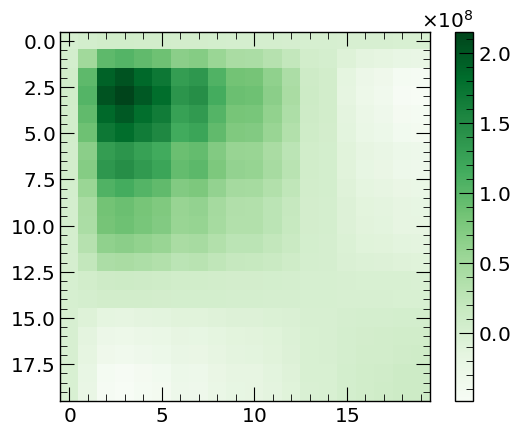

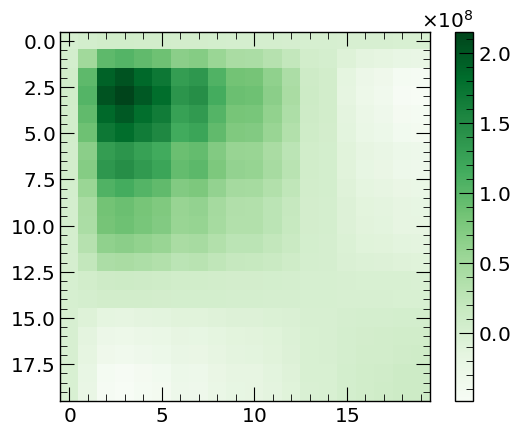

In [ ]:
plt.imshow(cov_reduced)
plt.colorbar()
plt.show()
plt.imshow(cov)
plt.colorbar()
plt.show()


In [164]:
len(_slcs_sel_background_nocosmic.data)+len(_slcs_sel_background[-1].data)

AttributeError: 'list' object has no attribute 'data'

In [165]:
np.concatenate([_genweights_sel_background_nocosmic,_genweights_sel_offbeam[0]]).sum()

972705.0343009067

In [166]:
_genweights_sel_background[-1].sum()

979463.0708706718

In [ ]:
np.concatenate([reco_bg_nocosmic_flashpe,reco_sel_flashpe_offbeam[0]])

In [ ]:
__flashpesystematics_cosmic = Systematics('flashpe', FLASHPE_BINS,
      reco_sel_flashpe[-1], np.concatenate([reco_bg_nocosmic_flashpe,reco_sel_flashpe_offbeam[0]]), 
      genweights_sig[-1], _genweights_sel[-1], 
      np.concatenate([_genweights_sel_background_nocosmic,_genweights_sel_offbeam[0]]),
      keys=['cosmic'],stype='Cosmic',pattern=None)

In [ ]:
__flashpesystematics = Systematics('flashpe', FLASHPE_BINS,
    reco_sel_flashpe[-1], reco_bg_flashpe[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
    keys=DET_VARS+CALO_VARS,stype='Det',pattern=None)

In [ ]:
__flashpesystematics.sel_background

array([126443.35996064,  58706.76310712,  41134.07351923,  32813.03828052,
        29493.85377264,  27238.40316507,  26645.15634026,  24994.2733467 ,
        24956.78132801,  24264.5919916 ,  23119.23917328,  21896.46188334,
        21129.41442437,  21371.57560725,  19316.05493307,  19275.25762774,
        18339.93785318,  17090.12076387,  16511.63989582,  15819.18547802])

In [ ]:
__flashpesystematics_cosmic.sel_background

array([71376.87567664, 22566.61140262, 17614.81339107, 18432.89173205,
       20679.25802895, 21083.76930052, 22382.0268643 , 20910.01899486,
       21473.61934882, 21252.35936417, 20704.12725359, 19312.02683004,
       19311.9526328 , 19287.51207519, 18061.20881387, 18008.43034976,
       17642.32712268, 16749.77000616, 15967.90493186, 14814.94440549])

In [128]:
_flashpesystematics.sel_background

array([126443.35996064,  58706.76310712,  41134.07351923,  32813.03828052,
        29493.85377264,  27238.40316507,  26645.15634026,  24994.2733467 ,
        24956.78132801,  24264.5919916 ,  23119.23917328,  21896.46188334,
        21129.41442437,  21371.57560725,  19316.05493307,  19275.25762774,
        18339.93785318,  17090.12076387,  16511.63989582,  15819.18547802])

In [118]:
_flashpesystematics_cosmic.systematics['cosmic']['sel']

[array([22513.39532863,  7629.46483561,  5364.33457259,  4963.84274047,
         5770.96111272,  5450.11892512,  5924.88854371,  5202.86835485,
         5481.90497899,  5646.28649768,  5682.59932305,  5106.2798045 ,
         5315.26292437,  5452.10882488,  5316.85006827,  5403.95510906,
         5567.50893458,  5428.71229839,  5162.90726562,  4797.73707716])]

In [120]:
_flashpesystematics_cosmic.sel+_flashpesystematics_cosmic.sel_background

array([26441.15884234, 13393.52534937,  6889.19019858,  5673.09318094,
        5342.22956644,  5306.45088477,  5374.26569578,  5433.31224026,
        5478.38159084,  5677.38307455,  5593.03536177,  5371.60767445,
        5386.37281014,  5617.29171604,  5104.19886513,  5280.52176587,
        5189.82429286,  4884.35175172,  4972.39203139,  4935.32217806])

In [124]:
_flashpesystematics.sel+_flashpesystematics.sel_background

array([126452.02838239,  58722.36626628,  41145.6314149 ,  32836.73196664,
        29553.37693532,  27373.05264959,  26877.47004317,  25315.58284624,
        25390.20241552,  24768.51624268,  23720.24974797,  22552.95035723,
        21872.00922098,  22181.20619872,  20158.04763241,  20149.61243495,
        19228.16213519,  18007.23978505,  17405.64312566,  16689.49502174])

In [ ]:
assert os.path.exists(f'{PLOT_DIR}/{cut}/dist'), ''

In [164]:
_opt0systematics.systematics['pmtgain'].keys()

dict_keys(['cols', 'col_names', 'type', 'name', 'variation', 'sigma_tilde', 'sel', 'xsec_cov', 'event_cov', 'xsec_corr', 'event_corr', 'xsec_fraccov', 'event_fraccov', 'xsec_fracunc', 'event_fracunc', 'event_totalunc', 'xsec_totalunc', 'label', 'description'])

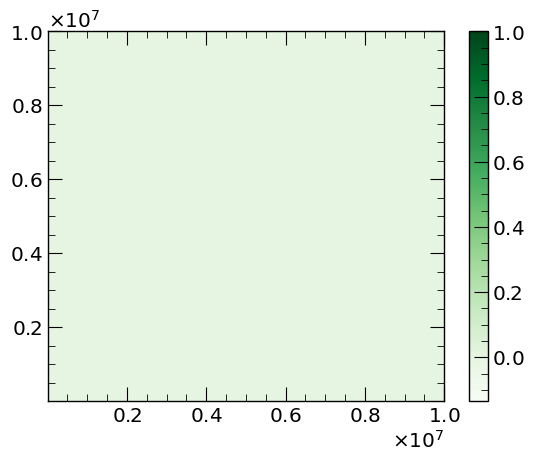

In [184]:
fig,ax = plt.subplots()
bins = _opt0systematics.bins
hist2d = _opt0systematics.systematics['pmtgain']['event_fraccov']
#Get hist2d, but replace Nan or Inf with 0
hist2d = np.nan_to_num(hist2d)
hist2d = np.where(np.isinf(hist2d), 0, hist2d)
hist2d = np.where(np.abs(hist2d) == np.finfo(np.double).max, 0, hist2d)
# Compute valid vmin/vmax for colorbar to avoid NaN/Inf limits
vmin = np.min(hist2d)
vmax = np.max(hist2d)
# Handle edge case where all values are the same or array is empty
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin = 0
    vmax = 1
vmin,vmax
im = ax.pcolormesh(bins,bins,hist2d,vmin=vmin,vmax=vmax)
fig.colorbar(im,ax=ax)

1.7976931348623157e+308

In [140]:
csystematics_slim = Systematics('costheta', costheta_bins, _reco_sel_costhetas_slim,
      _reco_bg_costhetas_slim, genweights_slim_sig, _genweights_sel_slim, _genweights_sel_background_slim,
      xsec_unit=XSEC_UNIT,
      true_sig=true_sig_costhetas_slim,
      true_sel=_true_sel_costhetas_slim,
      true_sel_background=_true_bg_costhetas_slim,stype='RW',keys=slc_slim_sig.data.truth.keys(),pattern=['GENIE','Flux','slim'])

(array([  0.,   0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,
          1.,   0.,   3.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
          0.,   1.,   2.,   0.,   0.,   0.,   0.,   1.,   0.,   2.,   5.,
          8.,  11.,  12.,  15.,  16.,  12.,  20.,  30.,  23.,  24.,  27.,
         28.,  39.,  38.,  47.,  41.,  41.,  35.,  39.,  59.,  47.,  46.,
         47.,  57.,  51.,  64.,  66.,  71.,  73.,  65.,  70.,  75.,  79.,
         85.,  84.,  62.,  84., 109., 100., 109., 137., 174., 186., 183.,
        196., 209., 241., 248., 325., 325., 309., 312., 368., 320., 461.,
        291., 254., 240., 251., 251., 254., 228., 246., 232., 243., 204.,
        167., 201., 168., 187., 167., 126., 197., 183., 150., 137.,  86.,
         88.,  92.,  74.,  71.,  61.,  50.,  40.,  22.,  13.,  20.,  22.,
         18.,  13.,  16.,  10.,  15.,   9.,  14.,   6.,   5.,  11.,   5.,
          7.,   3.,   9.,   3.,   4., 

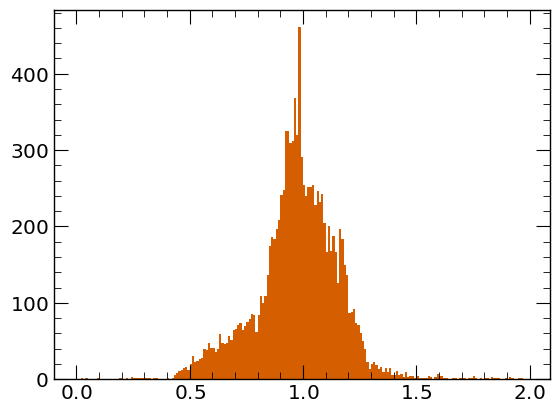

In [146]:
plt.hist(slc_slim_sig.data.truth.Flux.univ_0,bins=np.arange(0,2,0.01))

In [ ]:
#csystematics_slim.systematics['GENIE']

{'cols': [('truth', 'GENIE', 'univ_0', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_1', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_2', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_3', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_4', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_5', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_6', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_7', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_8', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_9', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_10', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_11', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_12', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_13', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_14', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_15', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_16', '', '', '', '', '', ''),
  ('truth', 'GENIE', 'univ_17', '

In [151]:
csystematics_slim.process_systematics(slc_slim_sig.data,_slc_slim_sel.data,progress_bar=True)

  0%|          | 0/3 [00:00<?, ? goomba/s]

100%|██████████| 3/3 [00:14<00:00,  4.90s/ goomba]


In [154]:
print('CV: ',csystematics_slim.sel+csystematics_slim.sel_background)
for i, var_sel in enumerate(csystematics_slim.systematics['GENIE']['sel']):
  print(f'Var {i}: {var_sel}')
  if i == 10:
    break


CV:  [ 5292.3743339   8944.00153823 26079.33913493 23303.6748223
 21748.13395707 18052.11538164 16402.35810149 12416.7637223
  8261.83944613]
Var 0: [ 5319.98241771  8941.46728102 26120.78275167 23382.67895936
 21913.8087098  18453.35864305 16784.16869217 13018.49903544
  8696.31773049]
Var 1: [ 5360.97567344  8772.44892355 26000.74223302 23294.30106216
 21604.68450348 18151.98592661 16959.35651595 13413.30664483
  9361.1768094 ]
Var 2: [ 5337.56736555  9038.91072741 26189.88396266 23269.89171033
 21712.36654617 18132.55614267 16234.66106891 12217.36260235
  7947.21523025]
Var 3: [ 5284.14085515  8761.34614869 25921.14384592 23194.49240928
 21547.03640237 17948.79014476 16670.4153975  13058.22805123
  8949.63736705]
Var 4: [ 5250.27152186  8736.479712   25931.73132388 23169.30798302
 21321.58453638 17636.55696677 16217.15116668 12340.84460603
  8155.571298  ]
Var 5: [ 5198.59459647  8838.19944628 25931.53478793 23128.64229111
 21293.37475163 17415.3734154  15834.87454575 11659.4287108


In [109]:
csystematics_slim = Systematics('costheta', costheta_bins, _reco_sel_costhetas_slim,
      _reco_bg_costhetas_slim, genweights_slim_sig, _genweights_sel_slim, _genweights_sel_background_slim,
      xsec_unit=XSEC_UNIT,
      true_sig=true_sig_costhetas_slim,
      true_sel=_true_sel_costhetas_slim,
      true_sel_background=_true_bg_costhetas_slim,stype='RW',keys=slc_slim_sig.data.truth.keys(),pattern=['GENIE','Flux','slim'])

In [110]:
csystematics_slim

Systematics(variable=costheta, keys=['Flux', 'GENIE', 'slim'])

## Testing

In [245]:
import uproot
fname = '/pnfs/sbn/data_add/sbn_nd/aurora/mc/v10_06_00_10/cv/000017/000170/reco2-2041-fd3a-8e9f-13ee.flat.caf.root'
tree = uproot.open(fname.replace('/pnfs',"root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr"))['recTree']

In [248]:
keys = ['rec.hdr.evt',
 'rec.hdr.run',
 'rec.hdr.subrun',]

In [249]:
df = tree.arrays(keys,library='pd')

In [250]:
df

,rec.hdr.evt,rec.hdr.run,rec.hdr.subrun
0,1,1426,31
1,2,1426,31
2,8,1426,31
3,9,1426,31
4,13,1426,31
...,...,...,...
95,34,1426,81
96,35,1426,81
97,40,1426,81
98,42,1426,81


In [247]:
[k for k in tree.keys() if 'run' in k or 'subrun' in k or 'evt' in k]

['rec.hdr.evt',
 'rec.hdr.first_in_subrun',
 'rec.hdr.ngenevt',
 'rec.hdr.run',
 'rec.hdr.subevt',
 'rec.hdr.subrun',
 'rec.mc.nu.genie_evtrec_idx',
 'rec.slc.truth.genie_evtrec_idx']

In [32]:
hdr = pd.read_hdf(f'{DATA_DIR}/{MC_FNAME}',key='hdr_0')

In [26]:
hdr.pot.sum()

1.5086108e+18